In [2]:
#Problem 1  
#Consider the following one-dimensional data points:
#X={2,4, 5, 10, 12, 13}

#Let K=2, with initial centroids:
#C_1=4, C_2=12

#Perform one complete iteration of K-Means:
#	Calculate the distance of every point from both centroids. 
#	Assign each point to the nearest centroid. 
#	Calculate the new centroids. 
#	State the cluster assignments after the first iteration. 

import numpy as np
import matplotlib.pyplot as plt

X = np.array([2, 4, 5, 10, 12, 13])
c1, c2 = 4, 12

print("Step 1: Calculate distance of every point from both centroids.")
dist_c1 = np.abs(X - c1)
dist_c2 = np.abs(X - c2)

for x, d1, d2 in zip(X, dist_c1, dist_c2):
    print(f"Point {x}: dist to C1({c1}) = {d1}, dist to C2({c2}) = {d2}")

print("\nStep 2: Assign each point to the nearest centroid.")
assignments = np.where(dist_c1 <= dist_c2, 1, 2)
cluster1 = X[assignments == 1]
cluster2 = X[assignments == 2]

print(f"Cluster 1: {cluster1.tolist()}")
print(f"Cluster 2: {cluster2.tolist()}")

print("\nStep 3: Calculate the new centroids.")
new_c1 = np.mean(cluster1) if len(cluster1) > 0 else c1
new_c2 = np.mean(cluster2) if len(cluster2) > 0 else c2
print(f"New Centroid 1: {new_c1:.2f}")
print(f"New Centroid 2: {new_c2:.2f}")



Step 1: Calculate distance of every point from both centroids.
Point 2: dist to C1(4) = 2, dist to C2(12) = 10
Point 4: dist to C1(4) = 0, dist to C2(12) = 8
Point 5: dist to C1(4) = 1, dist to C2(12) = 7
Point 10: dist to C1(4) = 6, dist to C2(12) = 2
Point 12: dist to C1(4) = 8, dist to C2(12) = 0
Point 13: dist to C1(4) = 9, dist to C2(12) = 1

Step 2: Assign each point to the nearest centroid.
Cluster 1: [2, 4, 5]
Cluster 2: [10, 12, 13]

Step 3: Calculate the new centroids.
New Centroid 1: 3.67
New Centroid 2: 11.67


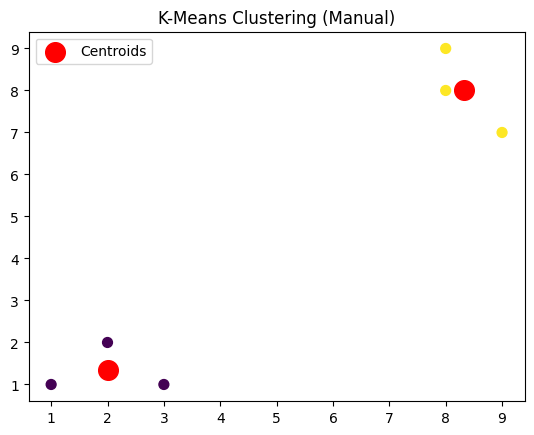

In [19]:
#Problem 2  
#Consider six points:

#Point	X	Y
#A	1	1
#B	2	2
#C	3	1
#D	8	8
#E	9	7
#F	8	9

#Let K=2and initial centroids be:
#C_1=(1, 1), C_2=(8, 8)

#Perform one iteration of K-Means and calculate the new centroids.

import numpy as np

def euclidean_distance(a, b):
    return np.linalg.norm(a - b, axis=1) 

def initialize_centroids(X, k):
    X_centroids = [(1, 1) , (8, 8)]
    centroids = np.array(X_centroids)
    return centroids
    
def assign_clusters(X, centroids):
    clusters = []
    for point in X:  
        distances = euclidean_distance(point, centroids)
        cluster = np.argmin(distances)
        clusters.append(cluster)
    return np.array(clusters)

def update_centroids(X, labels, k): #X       → data points
                                    #labels  → which cluster each point belongs to
                                    #k       → number of clusters
    new_centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) == 0:
            # Randomly re-initialize if a cluster gets no points
            new_centroids.append(X[np.random.choice(len(X))])
        else:
            new_centroids.append(cluster_points.mean(axis=0))
    return np.array(new_centroids)

def has_converged(old_centroids, new_centroids, tol=1e-4):
    return np.all(np.linalg.norm(old_centroids - new_centroids, axis=1) < tol)

def kmeans_from_scratch(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if has_converged(centroids, new_centroids):
            break
        centroids = new_centroids
    return centroids, labels

k = 2

X_array = [(1, 1), (2, 2), (3, 1), (8, 8), (9, 7), (8, 9)]
X = np.array(X_array)
centroids, labels = kmeans_from_scratch(X, k)

# Plot results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='o', label='Centroids')
plt.title("K-Means Clustering (Manual)")
plt.legend()
plt.show()    

In [20]:
#Problem 3   
#Given:
#X={1, 2, 3, 8, 9, 10}
#and K=2.
#Initial centroids:
#C_1=2, C_2=9

#After one iteration, calculate:
#	Cluster assignments 
#	New centroids 
#	Within-cluster SSE 
#This is a good exam question because students must understand that SSE is calculated using the final cluster assignments and their corresponding centroids.


import numpy as np

X = np.array([1, 2, 3, 8, 9, 10])
c1, c2 = 2, 9

# Iteration 1
# Step 1: Cluster Assignment
def assign_clusters(X, c1, c2):
    cluster1 = []
    cluster2 = []
    for x in X:
        dist1 = abs(x - c1)
        dist2 = abs(x - c2)
        if dist1 <= dist2:
            cluster1.append(x)
        else:
            cluster2.append(x)
    return cluster1, cluster2

cluster1, cluster2 = assign_clusters(X, c1, c2)
print("Initial Assignments:")
print("Cluster 1:", cluster1)
print("Cluster 2:", cluster2)

# Step 2: New Centroids
new_c1 = np.mean(cluster1)
new_c2 = np.mean(cluster2)
print("\nNew Centroids:")
print("C1:", new_c1)
print("C2:", new_c2)

# Step 3: Within-cluster SSE
sse1 = sum((x - new_c1)**2 for x in cluster1)
sse2 = sum((x - new_c2)**2 for x in cluster2)
total_sse = sse1 + sse2
print("\nWithin-cluster SSE:")
print("SSE Cluster 1:", sse1)
print("SSE Cluster 2:", sse2)
print("Total SSE:", total_sse)

Initial Assignments:
Cluster 1: [np.int64(1), np.int64(2), np.int64(3)]
Cluster 2: [np.int64(8), np.int64(9), np.int64(10)]

New Centroids:
C1: 2.0
C2: 9.0

Within-cluster SSE:
SSE Cluster 1: 2.0
SSE Cluster 2: 2.0
Total SSE: 4.0


In [29]:
#Problem 4  
#Consider the following points:
#A=(1, 1), B=(2, 2), C=(3, 3)
#D=(8, 8), E=(9, 9), F=(10, 10)

#For K=2, initial centroids are:
#C_1=(2, 2), C_2=(9, 9)

#a) Perform one complete K-Means iteration.
#b) Calculate the updated centroids.
#c) Calculate the total within-cluster SSE.
#d) Explain whether another iteration will change the cluster assignments.

import math

# 1. Define the given points and initial centroids
# The 'ⓜ' notation represents the coordinate value in a 2D plane.
points = {
    'A': (1, 1),
    'B': (2, 2),
    'C': (3, 3),
    'D': (8, 8),
    'E': (9, 9),
    'F': (10, 10)
}

c1 = (2, 2)
c2 = (9, 9)

def squared_euclidean_distance(p1, p2):
    return (p1[0] - p2[0])**2 + (p1[1] - p2[1])**2

# --- a) Perform one complete K-Means iteration ---
cluster1_points = []
cluster2_points = []

print("--- Step a) Distance Calculation & Initial Assignment ---")
for name, pt in points.items():
    dist_to_c1 = squared_euclidean_distance(pt, c1)
    dist_to_c2 = squared_euclidean_distance(pt, c2)
    
    if dist_to_c1 <= dist_to_c2:
        cluster1_points.append(name)
        print(f"Point {name}{pt}: Closer to C1 (Dist^2: {dist_to_c1} vs {dist_to_c2}) -> Assigned to Cluster 1")
    else:
        cluster2_points.append(name)
        print(f"Point {name}{pt}: Closer to C2 (Dist^2: {dist_to_c2} vs {dist_to_c1}) -> Assigned to Cluster 2")

print(f"\nCluster 1 elements: {cluster1_points}")
print(f"Cluster 2 elements: {cluster2_points}")


# --- b) Calculate the updated centroids ---
def calculate_centroid(cluster_names, points_dict):
    if not cluster_names:
        return (0, 0)
    sum_x = sum(points_dict[name][0] for name in cluster_names)
    sum_y = sum(points_dict[name][1] for name in cluster_names)
    n = len(cluster_names)
    return (sum_x / n, sum_y / n)

new_c1 = calculate_centroid(cluster1_points, points)
new_c2 = calculate_centroid(cluster2_points, points)

print("\n--- Step b) Updated Centroids ---")
print(f"Updated Centroid C1: {new_c1}")
print(f"Updated Centroid C2: {new_c2}")


# --- c) Calculate the total within-cluster SSE ---
sse_c1 = sum(squared_euclidean_distance(points[name], new_c1) for name in cluster1_points)
sse_c2 = sum(squared_euclidean_distance(points[name], new_c2) for name in cluster2_points)
total_sse = sse_c1 + sse_c2

print("\n--- Step c) Within-Cluster SSE ---")
print(f"SSE for Cluster 1: {sse_c1}")
print(f"SSE for Cluster 2: {sse_c2}")
print(f"Total Within-Cluster SSE: {total_sse}")


# --- d) Check if another iteration changes assignments ---
print("\n--- Step d) Checking for Convergence ---")
cluster1_iter2 = []
cluster2_iter2 = []

for name, pt in points.items():
    if squared_euclidean_distance(pt, new_c1) <= squared_euclidean_distance(pt, new_c2):
        cluster1_iter2.append(name)
    else:
        cluster2_iter2.append(name)

if cluster1_points == cluster1_iter2 and cluster2_points == cluster2_iter2:
    print("Explanation: Another iteration WILL NOT change the cluster assignments.")
    print("The clusters have already converged because the updated centroids match the initial ones exactly.")
else:
    print("Explanation: Another iteration WILL change the cluster assignments.")

--- Step a) Distance Calculation & Initial Assignment ---
Point A(1, 1): Closer to C1 (Dist^2: 2 vs 128) -> Assigned to Cluster 1
Point B(2, 2): Closer to C1 (Dist^2: 0 vs 98) -> Assigned to Cluster 1
Point C(3, 3): Closer to C1 (Dist^2: 2 vs 72) -> Assigned to Cluster 1
Point D(8, 8): Closer to C2 (Dist^2: 2 vs 72) -> Assigned to Cluster 2
Point E(9, 9): Closer to C2 (Dist^2: 0 vs 98) -> Assigned to Cluster 2
Point F(10, 10): Closer to C2 (Dist^2: 2 vs 128) -> Assigned to Cluster 2

Cluster 1 elements: ['A', 'B', 'C']
Cluster 2 elements: ['D', 'E', 'F']

--- Step b) Updated Centroids ---
Updated Centroid C1: (2.0, 2.0)
Updated Centroid C2: (9.0, 9.0)

--- Step c) Within-Cluster SSE ---
SSE for Cluster 1: 4.0
SSE for Cluster 2: 4.0
Total Within-Cluster SSE: 8.0

--- Step d) Checking for Convergence ---
Explanation: Another iteration WILL NOT change the cluster assignments.
The clusters have already converged because the updated centroids match the initial ones exactly.


In [ ]:
#Problem 5  
#For a dataset, the following SSE values are obtained:
#K	SSE
#1	1200
#2	650
#3	420
#4	350
#5	330
#6	320

#Questions:
#	Which value of K would you select using the Elbow Method? 
K = 3
#	Why would selecting K=6simply because it has the lowest SSE be misleading? 
SSE naturally decreases as \(K\) increases because adding more cluster centers brings them closer to individual data points.
At the extreme, if \(K\) equals the number of data points, SSE becomes 0. Choosing K=6 just for a lower 
SSE leads to overfitting, where you create artificial micro-clusters instead of capturing real, underlying patterns.
The drop from K=5 to K=6 is tiny (from 330 to 320), meaning the operational cost of handling an 
extra cluster provides almost no actual gain in data clustering quality.
#	What does the sharp reduction in SSE from K=1to K=3indicate? 
It indicates that the dataset has a highly defined, non-random cluster structure. Moving from 1 to 3 clusters captures the vast majority of the data's 
underlying variance. It shows that splitting the data into 2 and then 3 groups matches the natural geometry and groupings of the data perfectly. 
Beyond (K=3, you are just splitting these natural clusters into smaller, unnecessary pieces.
#This is a particularly good conceptual + numerical question.


In [ ]:
"""Problem 6  
Two different K-Means runs produce:
Run	K	SSE
A	2	250
B	3	180

A student concludes:
"Run B is definitely better because its SSE is lower."
Do you agree? Justify your answer.
"""
I do not completely agree.

Run B has a lower SSE (180 vs. 250), but it also uses more clusters (K = 3 vs. K = 2). In K-Means, SSE generally decreases as the number 
of clusters increases, so a lower SSE alone does not mean Run B is definitely better.

To decide which value of K is better, we should use a method such as the Elbow Method, Silhouette Score, or another validation criterion 
to balance clustering quality against model complexity.

Therefore Run B has lower SSE, but we cannot say it is definitely better without considering the appropriate number of clusters.
